In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
import umap

/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packag

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"


# UMAP 

Settings:

n_neighbors = 30

min_dist = 0.1

In [4]:
def draw_umap(data,
              features,
              metadata,
              cell_type, 
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_color = ["lightgray", "purple"]
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features);

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)

    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
    fig.suptitle(title, fontsize=18)
    
    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_inactive',
        palette = ["lightgray", "navy"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_Toxic',
        palette = ["lightgray", "purple"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_tubulin',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 2]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_DMSO',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Nocodazole',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Tetrandrine',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 2]
    )
    
    plt.savefig(filename)  

# Load and process annotations

In [5]:
annotation_compounds = pd.read_csv(annot_path + "pd_export_04_2022_2464_compounds_standardized.csv")
annotation_compounds.columns = annotation_compounds.columns.str.replace(' ', '_')
annotation_compounds = annotation_compounds.add_prefix('Metadata_')

In [6]:
annotation_targets = pd.read_csv(annot_path + 'pd_export_04_2022_2464_targets_standardized.csv')
annotation_targets.columns = annotation_targets.columns.str.replace(' ', '_')
annotation_targets = annotation_targets.add_prefix('Metadata_')
annotation_targets.shape

(29915, 31)

In [7]:
id_file = pd.read_csv(annot_path + "2024-08-02_EOS_pdid.csv")
id_file.shape

(2464, 2)

In [8]:
annotation_tubulin = pd.read_csv(annot_path + "2024-08-02_Tubulin.csv")
annotation_tubulin.shape

(2464, 2)

In [9]:
# get EUOS number 
annotation_compounds = pd.merge(annotation_compounds,
                     annotation_tubulin,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

In [10]:
# get EUOS number 
annotation_compounds_2 = pd.merge(annotation_compounds,
                     id_file,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

# IMTM Hep G2

## Load Normalized data

In [11]:
# Load normalized data
file_MEDINA_HepG2_type = '/*[0-9]_' + 'MEDINA_HepG2_norm.csv'
files_MEDINA_HepG2 = glob.glob(input_path + file_MEDINA_HepG2_type)

### gets latest file
max_file_MEDINA_HepG2 = max(files_MEDINA_HepG2, key=os.path.getctime)

### load file
data_MEDINA_HepG2_Norm = pd.read_csv(max_file_MEDINA_HepG2)
data_MEDINA_HepG2_Norm.shape

(10735, 2984)

In [12]:
# Feature reduction
print("Feature reduction with correlation threshold 0.9 and Outlier threshold 100")
MEDINA_HepG2_Reduced_Carsten_100_Mod = UTIL.feature_reduction(data_MEDINA_HepG2_Norm, 
                                         variance_freq_cut=0.1, 
                                         variance_unique_cut=0.1, 
                                         outlier_cutoff=100, 
                                         corr_threshold = 0.9, 
                                         print_stats = True)

Feature reduction with correlation threshold 0.9 and Outlier threshold 100
| Category           |   Original Features |   Variance Threshold |   % Variance |   Outlier Threshold |   % Outlier |   Correlation Threshold |   % Correlation |
|:-------------------|--------------------:|---------------------:|-------------:|--------------------:|------------:|------------------------:|----------------:|
| Total Features     |                2977 |                 2807 |         94.3 |                2309 |        77.6 |                     575 |            19.3 |
| Intensity          |                 180 |                  180 |        100   |                 167 |        92.8 |                      40 |            22.2 |
| Correlation        |                 180 |                  120 |         66.7 |                 103 |        57.2 |                      78 |            43.3 |
| AreaShape          |                 162 |                  153 |         94.4 |                 128 |      

## Remove non reproducible compounds

In [13]:
# Load non replicating compounds
file_MEDINA_HepG2_nonreplicating_type = '/*[0-9]_' + 'MEDINA_HepG2_non-replicating.csv'
files_MEDINA_HepG2_nonreplicating = glob.glob(input_path + file_MEDINA_HepG2_nonreplicating_type)

### gets latest file
max_files_MEDINA_HepG2_nonreplicating = max(files_MEDINA_HepG2_nonreplicating, key=os.path.getctime)

### load file
data_MEDINA_HepG2_nonreplicating = pd.read_csv(max_files_MEDINA_HepG2_nonreplicating)
data_MEDINA_HepG2_nonreplicating.shape

(104, 1)

In [14]:
# Get replicating compound by removing non replicating compounds
MEDINA_HepG2_Data_replicating = MEDINA_HepG2_Reduced_Carsten_100_Mod.loc[~MEDINA_HepG2_Reduced_Carsten_100_Mod["Metadata_EOS"].isin(data_MEDINA_HepG2_nonreplicating["Metadata_EOS"])].copy()
MEDINA_HepG2_Data_replicating.shape

(10322, 582)

## Get low active compounds

In [15]:
# Load low active compounds
file_MEDINA_HepG2_inactive_type = '/*[0-9]_' + 'MEDINA_HepG2_low-active.csv'
files_MEDINA_HepG2_inactive = glob.glob(input_path + file_MEDINA_HepG2_inactive_type)

### gets latest file
max_file_MEDINA_HepG2_inactive = max(files_MEDINA_HepG2_inactive, key=os.path.getctime)

### load file
data_MEDINA_HepG2_inactive = pd.read_csv(max_file_MEDINA_HepG2_inactive)
data_MEDINA_HepG2_inactive.shape

(1542, 1)

In [16]:
data_MEDINA_HepG2_inactive_annot = pd.merge(data_MEDINA_HepG2_inactive,
                               id_file,
                               on = ["Metadata_EOS"],
                               how = "left",
                               indicator = True)

In [17]:
annotation_compounds_2['Metadata_MEDINA_HepG2_inactive'] = annotation_compounds_2['Metadata_pdid'].isin(data_MEDINA_HepG2_inactive_annot['Metadata_pdid'])

## Get toxic compounds

In [18]:
# data_U2OS_Median = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm_reduced_filtered_median.csv")
file_MEDINA_HepG2_tox_type = '/*[0-9]_' + 'MEDINA_HepG2_toxic_all.csv'
files_MEDINA_HepG2_tox = glob.glob(output_path + file_MEDINA_HepG2_tox_type)

### gets latest file
max_file_MEDINA_HepG2_tox = max(files_MEDINA_HepG2_tox, key=os.path.getctime)

### load file
data_MEDINA_HepG2_tox = pd.read_csv(max_file_MEDINA_HepG2_tox)
data_MEDINA_HepG2_tox.shape

(81, 1)

In [19]:
data_MEDINA_HepG2_tox_annot = pd.merge(data_MEDINA_HepG2_tox,
                               id_file,
                               on = ["Metadata_EOS"],
                               how = "left",
                               indicator = True)

In [20]:
annotation_compounds_2['Metadata_MEDINA_HepG2_Toxic'] = annotation_compounds_2['Metadata_pdid'].isin(data_MEDINA_HepG2_tox_annot['Metadata_pdid'])

## Process for visualization

In [21]:
## gets feature vector
Features_MEDINA_HepG2_Norm_Reduced = UTIL.get_feature_vector(MEDINA_HepG2_Data_replicating)

# Compute consensus
Features_MEDINA_HepG2_Norm_Reduced_Median = pycytominer.consensus(
        profiles = MEDINA_HepG2_Data_replicating, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_MEDINA_HepG2_Norm_Reduced, # (str, list) – The features to collapse, defaults to “infer”
)

In [22]:
MEDINA_HepG2_Norm_Reduced_Median_annot = pd.merge(Features_MEDINA_HepG2_Norm_Reduced_Median,
                                              annotation_compounds_2,
                                              how = 'left',
                                              on=['Metadata_EOS'])

In [23]:
MEDINA_HepG2_Norm_Reduced_Median_annot['Metadata_Nocodazole'] = MEDINA_HepG2_Norm_Reduced_Median_annot['Metadata_EOS'].str.contains('Nocodazole', case=False, na=False)
MEDINA_HepG2_Norm_Reduced_Median_annot['Metadata_Tetrandrine'] = MEDINA_HepG2_Norm_Reduced_Median_annot['Metadata_EOS'].str.contains('Tetrandrine', case=False, na=False)
MEDINA_HepG2_Norm_Reduced_Median_annot['Metadata_DMSO'] = MEDINA_HepG2_Norm_Reduced_Median_annot['Metadata_EOS'].str.contains('DMSO', case=False, na=False)

In [24]:
# Data without metadata columns
MEDINA_HepG2_Data = MEDINA_HepG2_Norm_Reduced_Median_annot.reset_index(drop = True)
MEDINA_HepG2_Features = UTIL.get_feature_vector(MEDINA_HepG2_Data)
MEDINA_HepG2_Meta_Features = list(set(MEDINA_HepG2_Data.columns) - set(MEDINA_HepG2_Features ))
    

MEDINA_HepG2_x = MEDINA_HepG2_Data.loc[:, MEDINA_HepG2_Features]

In [25]:
# change table data formats for specific columns
MEDINA_HepG2_Data['Metadata_tubulin'].fillna(False,inplace=True)
MEDINA_HepG2_Data['Metadata_MEDINA_HepG2_Toxic'].fillna(False,inplace=True)
MEDINA_HepG2_Data['Metadata_MEDINA_HepG2_inactive'].fillna(False,inplace=True)

## Visualize with UMAP

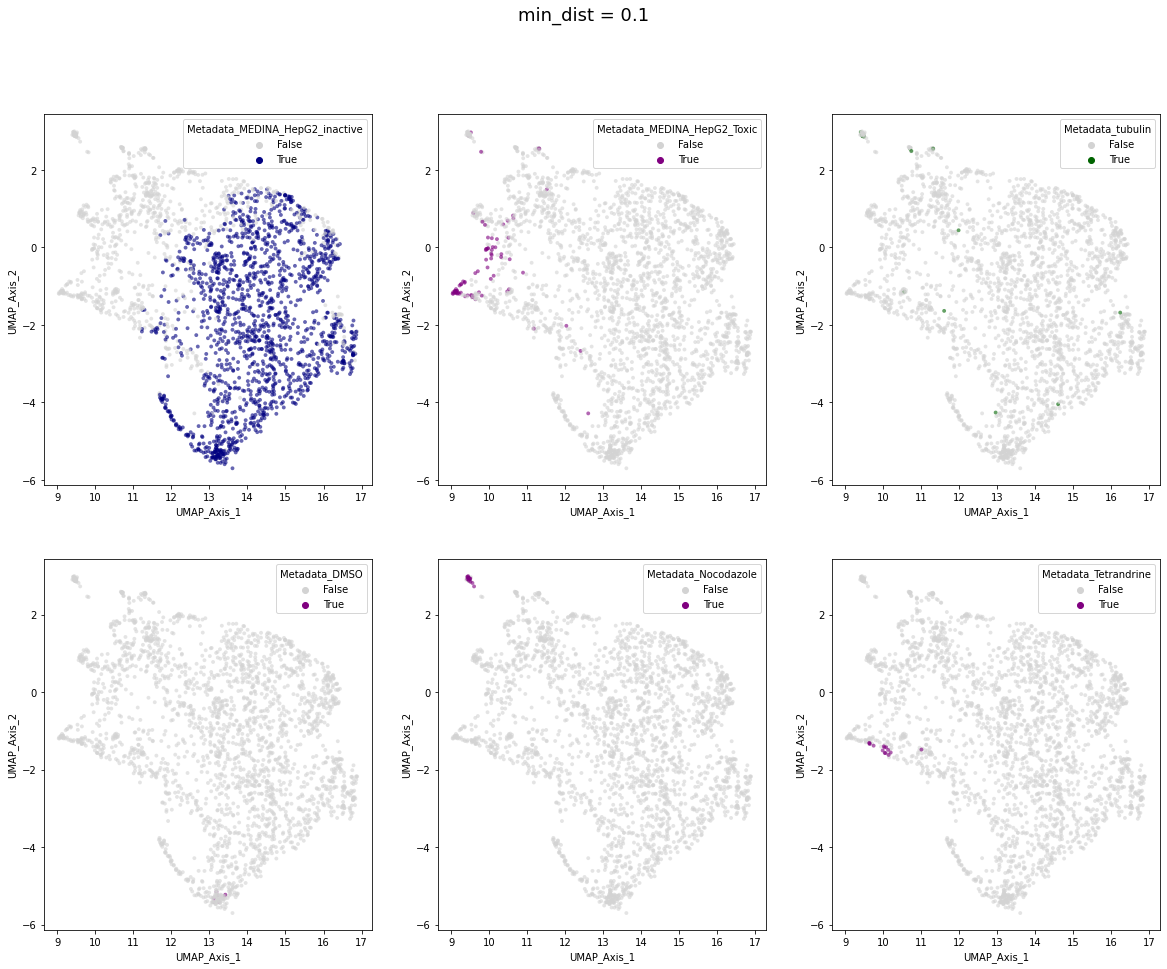

In [26]:
filename_MEDINA_HepG2_UMAP = figure_path + str(date.today()) + "_MEDINA_HepG2_UMAP_2D_VizOnly.pdf"

draw_umap(data = MEDINA_HepG2_Data,
          features = MEDINA_HepG2_x,
          metadata = MEDINA_HepG2_Meta_Features,
          cell_type='MEDINA_HepG2',
          n_neighbors=30,
          min_dist=0.1,
          title='min_dist = {}'.format(0.1),
          filename = filename_MEDINA_HepG2_UMAP)

# Number and precent toxic, low active

## Toxic

In [27]:
# precent toxic all U2OS
number_all = len(annotation_compounds_2)

number_toxic = len(annotation_compounds_2[
    annotation_compounds_2['Metadata_MEDINA_HepG2_Toxic']])

print('Precent toxic all cpds in MEDINA_HepG2: ', ( number_toxic / number_all ) * 100 )

Precent toxic all cpds in MEDINA_HepG2:  3.125


## Activity

In [28]:
# precent toxic all U2OS
number_all = len(annotation_compounds_2)

number_inactive = len(annotation_compounds_2[
    annotation_compounds_2['Metadata_MEDINA_HepG2_inactive']])

print('Precent inactive cpds in MEDINA_HepG2: ', ( number_inactive / number_all ) * 100 )

Precent inactive cpds in MEDINA_HepG2:  62.54058441558441
